# Euro 500 Index Returns

Dieses Notebook baut den Euro-500-Marktindex auf Daily-Basis, vergleicht ihn mit STOXX-Benchmarks und erzeugt firmenspezifische Risikokennzahlen.

## Workflow

1. Free-Float-Gewichte (quartalsweise Rebalancierung)
2. Daily Market Return inkl. Risk-Free-Serie
3. Index-Diagnostik
4. Benchmark-Pull (STOXX 600 / STOXX EURO 50)
5. Relative-Performance-Ansichten
6. Rolling CAPM-Beta je Firma
7. Abnormal Returns je Firma


In [1]:
# --- Imports & configuration ---
from pathlib import Path
import pandas as pd
import numpy as np
import lseg.data as ld
import warnings
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter, FuncFormatter
from plot_style import COLORS, set_global_plot_style, style_axes, style_legend, style_time_axis
set_global_plot_style()
BASE_DIR = Path("/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data")
(DATA_DIR := BASE_DIR / "intermediate").mkdir(parents=True, exist_ok=True)
(CACHE_DATA_DIR := BASE_DIR / "cache").mkdir(parents=True, exist_ok=True)
warnings.filterwarnings(
    "ignore",
    message=r".*Downcasting behavior in `replace` is deprecated.*",
    category=FutureWarning,
    module=r"lseg\.data\._tools\._dataframe"
)


In [2]:
# --- Prerequisite data for Step 4 ---
EURO500_PATH = DATA_DIR / "euro500.parquet"
if not EURO500_PATH.exists():
    raise FileNotFoundError(f"Missing file: {EURO500_PATH}")
euro500 = pd.read_parquet(EURO500_PATH).copy()
print("Loaded:", EURO500_PATH)
print("Rows:", len(euro500))


Loaded: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500.parquet
Rows: 56500


## 1. Free-Float Market-Cap Weights (Quarterly Rebalanced)

**Ziel**
- Konstruktion quartalsweiser Portfolio-Gewichte auf Basis der Free-Float-Marktkapitalisierung.

**Methode**
- Für jedes Quartal `q`:
$$
w_{i,q}=\frac{FFMCAP_{i,q}}{\sum_j FFMCAP_{j,q}}
$$
- Gewichte sind innerhalb des Quartals konstant, Rebalancing zum nächsten Quartalsstichtag.

**Input**
- `Project_Data/intermediate/euro500.parquet`

**Output (bearbeitet)**
- In-Memory: `weights_ff`
- Keine Datei wird in diesem Schritt geschrieben.


In [3]:
def build_quarterly_ff_weights(euro500_df: pd.DataFrame) -> pd.DataFrame:
    required_base = ["quarter", "date", "effective_date", "mcap_eur", "FreeFloatPct"]
    missing_base = [c for c in required_base if c not in euro500_df.columns]
    if missing_base:
        raise ValueError(f"Missing required columns for weight build: {missing_base}")

    w = euro500_df.copy()

    # Backward compatibility: build firm_id if not yet present in loaded euro500.
    if "firm_id" not in w.columns:
        out = pd.Series(pd.NA, index=w.index, dtype="string")

        if "ISIN" in w.columns:
            v = w["ISIN"].astype("string").str.strip()
            v = v.where(v.notna() & (v != ""), pd.NA)
            out = out.fillna("ISIN:" + v)

        if "RIC_current" in w.columns:
            v = w["RIC_current"].astype("string").str.strip()
            v = v.where(v.notna() & (v != ""), pd.NA)
            out = out.fillna("RIC:" + v)

        if "RIC" in w.columns:
            v = w["RIC"].astype("string").str.strip()
            v = v.where(v.notna() & (v != ""), pd.NA)
            out = out.fillna("RIC:" + v)

        if "SEDOL" in w.columns:
            v = w["SEDOL"].astype("string").str.strip()
            v = v.where(v.notna() & (v != ""), pd.NA)
            out = out.fillna("SEDOL:" + v)

        w["firm_id"] = out

    w["mcap_eur"] = pd.to_numeric(w["mcap_eur"], errors="coerce")
    w["FreeFloatPct"] = pd.to_numeric(w["FreeFloatPct"], errors="coerce")
    w["firm_id"] = w["firm_id"].astype("string").str.strip()
    w = w[w["firm_id"].notna() & (w["firm_id"] != "")].copy()

    # Supports both 0-100 and 0-1 free-float formats.
    ff_raw = pd.to_numeric(w["FreeFloatPct"], errors="coerce").to_numpy(dtype="float64", na_value=np.nan)
    ff_frac = np.where(ff_raw > 1.0, ff_raw / 100.0, ff_raw)
    w["ff_frac_used"] = pd.Series(ff_frac, index=w.index).clip(lower=0.0, upper=1.0)
    w["ff_frac_used"] = w["ff_frac_used"].fillna(1.0)

    w["ff_mcap_eur"] = w["mcap_eur"] * w["ff_frac_used"]
    w = w.dropna(subset=["ff_mcap_eur"]).copy()

    # Keep one line per quarter + firm_id (largest ff_mcap if duplicates exist).
    w = (
        w.sort_values(["quarter", "firm_id", "ff_mcap_eur"], ascending=[True, True, False])
        .drop_duplicates(subset=["quarter", "firm_id"], keep="first")
        .copy()
    )

    q_sum = w.groupby("quarter")["ff_mcap_eur"].transform("sum")
    w["weight_ff_mcap"] = np.where(q_sum > 0, w["ff_mcap_eur"] / q_sum, np.nan)

    out_cols = [
        "quarter",
        "date",
        "effective_date",
        "firm_id",
        "ISIN",
        "RIC",
        "name",
        "mcap_eur",
        "FreeFloatPct",
        "ff_frac_used",
        "ff_mcap_eur",
        "weight_ff_mcap",
        "rank_mcap",
    ]
    out_cols = [c for c in out_cols if c in w.columns]
    out = w[out_cols].sort_values(["quarter", "weight_ff_mcap"], ascending=[True, False]).reset_index(drop=True)
    return out


weights_ff = build_quarterly_ff_weights(euro500)

weights_qc = (
    weights_ff.groupby("quarter", as_index=False)
    .agg(
        n_constituents=("firm_id", "nunique"),
        weight_sum=("weight_ff_mcap", "sum"),
        ff_mcap_total=("ff_mcap_eur", "sum"),
    )
)
print("Quarterly weights quality check:")
display(weights_qc.head())
display(weights_qc.tail())

Quarterly weights quality check:


,quarter,n_constituents,weight_sum,ff_mcap_total
0,1998Q1,500,1.0,924974824254.137695
1,1998Q2,500,1.0,1368704672100.7146
2,1998Q3,500,1.0,1485947193115.250488
3,1998Q4,500,1.0,1152769034853.703857
4,1999Q1,500,1.0,1362409800770.108887


,quarter,n_constituents,weight_sum,ff_mcap_total
108,2025Q1,500,1.0,5681777172798.492188
109,2025Q2,500,1.0,6110905809377.236328
110,2025Q3,500,1.0,6318190626598.301758
111,2025Q4,500,1.0,6544643949657.299805
112,2026Q1,500,1.0,6843051270078.774414


## 2. Daily Market Return and Risk-Free Integration

**Ziel**
- Konstruktion der täglichen Euro-500-Marktrendite und Zuordnung der täglichen Risk-Free-Rate.

**Methode**
- Daily Indexrendite (gewichteter Querschnitt):
$$
r_{m,t}=\frac{\sum_i w_{i,q(t)}\,r_{i,t}}{\sum_i w_{i,q(t)}}
$$
- Zusätzliche robuste Variante mit Mindestabdeckung (`capped80`).
- Risk-Free: ECB €STR (mit historischer Ergänzung via EONIA), inkl. Daily-Konvertierung.

**Input**
- `Project_Data/intermediate/euro500_daily_returns.parquet`
- In-Memory: `weights_ff`
- ECB API (für RF, mit lokalem Cache)

**Output (bearbeitet)**
- In-Memory: `market_daily_out`
- Cache-Dateien unter `Project_Data/cache/rf_cache/`


In [4]:
RETURNS_IN_INDEX_PATH = DATA_DIR / "euro500_daily_returns.parquet"
if not RETURNS_IN_INDEX_PATH.exists():
    raise FileNotFoundError(f"Missing file: {RETURNS_IN_INDEX_PATH}")

returns_in_index = pd.read_parquet(RETURNS_IN_INDEX_PATH)
returns_in_index["date"] = pd.to_datetime(returns_in_index["date"], errors="coerce")
returns_in_index["ret"] = pd.to_numeric(returns_in_index["ret"], errors="coerce")
returns_in_index["quarter"] = returns_in_index["quarter"].astype(str)


def _build_firm_id(df: pd.DataFrame) -> pd.Series:
    out = pd.Series(pd.NA, index=df.index, dtype="string")

    if "ISIN" in df.columns:
        v = df["ISIN"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        out = out.fillna("ISIN:" + v)

    if "RIC_current" in df.columns:
        v = df["RIC_current"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        out = out.fillna("RIC:" + v)

    if "RIC" in df.columns:
        v = df["RIC"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        out = out.fillna("RIC:" + v)

    if "SEDOL" in df.columns:
        v = df["SEDOL"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        out = out.fillna("SEDOL:" + v)

    return out


if "firm_id" in returns_in_index.columns:
    returns_in_index["firm_id"] = returns_in_index["firm_id"].astype("string").str.strip()
    returns_in_index.loc[returns_in_index["firm_id"] == "", "firm_id"] = pd.NA
    # keep existing firm_id (expected: stable FIRMxxxx ids) and only fill true missing values
    returns_in_index["firm_id"] = returns_in_index["firm_id"].fillna(_build_firm_id(returns_in_index))
else:
    returns_in_index["firm_id"] = _build_firm_id(returns_in_index)

weights_join = weights_ff[["quarter", "firm_id", "weight_ff_mcap"]].copy()
weights_join["quarter"] = weights_join["quarter"].astype(str)
weights_join["firm_id"] = weights_join["firm_id"].astype(str).str.strip()

idx_daily = returns_in_index.merge(
    weights_join,
    on=["quarter", "firm_id"],
    how="inner",
)
idx_daily = idx_daily.dropna(subset=["date", "ret", "weight_ff_mcap"]).copy()
idx_daily["weighted_ret"] = idx_daily["ret"] * idx_daily["weight_ff_mcap"]

market_daily = (
    idx_daily
    .groupby(["date", "quarter"], as_index=False)
    .agg(
        market_return_num=("weighted_ret", "sum"),
        weight_available=("weight_ff_mcap", "sum"),
        n_constituents_with_return=("firm_id", "nunique"),
    )
)
market_daily["market_return_ffmcap"] = np.where(
    market_daily["weight_available"] > 0,
    market_daily["market_return_num"] / market_daily["weight_available"],
    np.nan,
)
MIN_WEIGHT_AVAILABLE = 0.80
market_daily["market_return_ffmcap_capped80"] = np.where(
    market_daily["weight_available"] >= MIN_WEIGHT_AVAILABLE,
    market_daily["market_return_ffmcap"],
    np.nan,
)

market_daily = market_daily.sort_values(["date", "quarter"]).reset_index(drop=True)
market_daily_out = market_daily[[
    "date",
    "quarter",
    "market_return_ffmcap",
    "market_return_ffmcap_capped80",
    "weight_available",
    "n_constituents_with_return",
]]

# --- Daily risk-free rate (EUR): EUR Short-Term Rate (€STR) ---
RF_CACHE_DIR = CACHE_DATA_DIR / "rf_cache"
RF_CACHE_DIR.mkdir(parents=True, exist_ok=True)
RF_CACHE_SCHEMA_VERSION = "v2"
RF_END_CAP = pd.Timestamp("2026-01-31")


def _rf_cache_path(start: pd.Timestamp, end: pd.Timestamp) -> Path:
    s = pd.to_datetime(start).strftime("%Y%m%d")
    e = pd.to_datetime(end).strftime("%Y%m%d")
    return RF_CACHE_DIR / f"rf_estr_{RF_CACHE_SCHEMA_VERSION}_{s}_{e}.parquet"


def _parse_rf_cache_dates(path: Path) -> tuple[pd.Timestamp, pd.Timestamp] | None:
    m = re.match(rf"^rf_estr_{RF_CACHE_SCHEMA_VERSION}_(\d{{8}})_(\d{{8}})\.parquet$", path.name)
    if not m:
        return None
    s = pd.to_datetime(m.group(1), format="%Y%m%d", errors="coerce")
    e = pd.to_datetime(m.group(2), format="%Y%m%d", errors="coerce")
    if pd.isna(s) or pd.isna(e):
        return None
    return s, e


def _coerce_num(s: pd.Series) -> pd.Series:
    t = s.astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False).str.strip()
    t = t.replace({"": np.nan, "None": np.nan, "nan": np.nan})
    return pd.to_numeric(t, errors="coerce")


def _api_date_value_cols(df: pd.DataFrame) -> tuple[str, str]:
    date_candidates = [c for c in df.columns if "TIME" in c.upper() and "PERIOD" in c.upper()]
    value_candidates = [c for c in df.columns if c.upper() in {"OBS_VALUE", "OBSVALUE", "VALUE"}]
    if not date_candidates or not value_candidates:
        raise ValueError(f"ECB API response schema unexpected. Columns={list(df.columns)}")
    return date_candidates[0], value_candidates[0]


def _to_daily_rate(out: pd.DataFrame, annual_col: str) -> pd.DataFrame:
    out = out.dropna(subset=["date", annual_col]).sort_values("date")
    if out.empty:
        return out

    good = out[annual_col] > -1.0
    out["rf_daily"] = np.nan
    out.loc[good, "rf_daily"] = np.expm1(np.log1p(out.loc[good, annual_col]) / 360.0)
    return out


def _pull_ecb_est(start_str: str, end_str: str) -> pd.DataFrame:
    # €STR (annualized % rate)
    ecb_series = "EST.B.EU000A2X2A25.WT"
    ecb_url = (
        "https://data-api.ecb.europa.eu/service/data/EST/B.EU000A2X2A25.WT"
        f"?startPeriod={start_str}&endPeriod={end_str}&format=csvdata"
    )
    df = pd.read_csv(ecb_url)
    dcol, vcol = _api_date_value_cols(df)
    out = pd.DataFrame({
        "date": pd.to_datetime(df[dcol], errors="coerce"),
        "rf_annual": pd.to_numeric(df[vcol], errors="coerce") / 100.0,
    })
    out["rf_source"] = "€STR"
    return _to_daily_rate(out, annual_col="rf_annual")


def _pull_ecb_eonia(start_str: str, end_str: str) -> pd.DataFrame:
    # EONIA (historical overnight benchmark, annualized %).
    # We query dataset-level CSV and isolate the central EONIA rate series.
    ecb_url = (
        "https://data-api.ecb.europa.eu/service/data/EON"
        f"?startPeriod={start_str}&endPeriod={end_str}&format=csvdata"
    )
    df = pd.read_csv(ecb_url)
    dcol, vcol = _api_date_value_cols(df)

    text_cols = [c for c in df.columns if c not in {dcol, vcol}]
    joined = (
        df[text_cols].astype(str).fillna("").agg(" ".join, axis=1).str.upper()
        if text_cols else pd.Series([""] * len(df))
    )

    mask_core = joined.str.contains("EONIA", na=False)
    mask_excl = joined.str.contains("25PCT|75PCT|VOLUME|VOL", na=False, regex=True)
    m = mask_core & (~mask_excl)
    dfx = df.loc[m].copy() if m.any() else df.copy()

    # If multiple series remain, keep the one with most observations.
    series_cols = [c for c in dfx.columns if c not in {dcol, vcol}]
    if series_cols:
        cnt = (
            dfx.assign(__k=dfx[series_cols].astype(str).agg("|".join, axis=1))
            .groupby("__k", as_index=False)[vcol]
            .count()
            .sort_values(vcol, ascending=False)
        )
        if not cnt.empty:
            best = cnt.iloc[0]["__k"]
            dfx = dfx[dfx[series_cols].astype(str).agg("|".join, axis=1) == best].copy()

    out = pd.DataFrame({
        "date": pd.to_datetime(dfx[dcol], errors="coerce"),
        "rf_annual": pd.to_numeric(dfx[vcol], errors="coerce") / 100.0,
    })
    out["rf_source"] = "EONIA"
    return _to_daily_rate(out, annual_col="rf_annual")


def pull_estr_daily(start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    start = pd.to_datetime(start, errors="coerce")
    end = pd.to_datetime(end, errors="coerce")
    if pd.isna(start) or pd.isna(end):
        raise ValueError(f"Invalid rf date bounds: start={start}, end={end}")

    start_str = start.strftime("%Y-%m-%d")
    end_str = end.strftime("%Y-%m-%d")

    try:
        est = _pull_ecb_est(start_str=start_str, end_str=end_str)
    except Exception as e:
        raise ValueError(f"ECB €STR pull failed: {type(e).__name__}: {e}")

    try:
        eon = _pull_ecb_eonia(start_str=start_str, end_str=end_str)
    except Exception:
        # If EONIA lookup fails, keep pure €STR (short history).
        eon = pd.DataFrame(columns=["date", "rf_annual", "rf_daily", "rf_source"])

    # Splice rule: use €STR where available; otherwise fallback to EONIA.
    rf = pd.concat([eon, est], ignore_index=True)
    rf = rf.dropna(subset=["date"]).sort_values(["date", "rf_source"]).copy()

    # prefer €STR over EONIA on overlapping dates
    prio = {"EONIA": 0, "€STR": 1}
    rf["_prio"] = rf["rf_source"].map(prio).fillna(0)
    rf = rf.sort_values(["date", "_prio"]).drop_duplicates(subset=["date"], keep="last")

    rf["ric_used"] = "ECB:EST.B.EU000A2X2A25.WT + EON(dataset)"
    rf["field_used"] = "OBS_VALUE"
    rf["rf_estr_annual"] = rf["rf_annual"]

    return rf[["date", "rf_estr_annual", "rf_daily", "ric_used", "field_used", "rf_source"]].sort_values("date").reset_index(drop=True)


def pull_estr_daily_cached(start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    start = pd.to_datetime(start, errors="coerce")
    end = pd.to_datetime(end, errors="coerce")
    if pd.isna(start) or pd.isna(end):
        raise ValueError(f"Invalid rf date bounds: start={start}, end={end}")

    requested_end = end
    end = min(end, RF_END_CAP)
    if end < start:
        raise ValueError(f"RF end cap {RF_END_CAP.date()} is earlier than start {start.date()}")
    if requested_end > end:
        print(f"RF end capped at {end.date()} (requested {requested_end.date()})")

    cache_path = _rf_cache_path(start=start, end=end)
    if cache_path.exists():
        out = pd.read_parquet(cache_path)
        out["date"] = pd.to_datetime(out["date"], errors="coerce")
        out = out.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
        print(f"RF cache hit: {cache_path.name}")
        return out

    cache_files = []
    for p in RF_CACHE_DIR.glob(f"rf_estr_{RF_CACHE_SCHEMA_VERSION}_*.parquet"):
        parsed = _parse_rf_cache_dates(p)
        if parsed is not None:
            s, e = parsed
            cache_files.append((p, s, e))

    # Full coverage from an existing cache file (different filename/range).
    covering = [(p, s, e) for (p, s, e) in cache_files if (s <= start and e >= end)]
    if covering:
        p, s, e = min(covering, key=lambda x: (x[2] - x[1], x[2]))
        out = pd.read_parquet(p)
        out["date"] = pd.to_datetime(out["date"], errors="coerce")
        out = out[(out["date"] >= start) & (out["date"] <= end)].copy()
        out = out.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
        print(f"RF cache hit (covering): {p.name} -> slice {start.date()}..{end.date()}")
        out.to_parquet(cache_path, index=False)
        return out

    # Partial reuse: extend the best cache that starts early enough and ends closest before requested end.
    partial = [(p, s, e) for (p, s, e) in cache_files if (s <= start and e < end)]
    if partial:
        p, s, e = max(partial, key=lambda x: x[2])
        base = pd.read_parquet(p)
        base["date"] = pd.to_datetime(base["date"], errors="coerce")
        base = base[(base["date"] >= start) & (base["date"] <= e)].copy()

        pull_start = max(start, e + pd.Timedelta(days=1))
        print(f"RF cache partial hit: {p.name} -> pulling missing {pull_start.date()}..{end.date()}")
        tail = pull_estr_daily(start=pull_start, end=end)

        out = pd.concat([base, tail], ignore_index=True)
        out = out.dropna(subset=["date"]).sort_values("date").drop_duplicates(subset=["date"], keep="last").reset_index(drop=True)
        out.to_parquet(cache_path, index=False)
        return out

    print("RF cache miss -> pulling €STR from ECB API")
    out = pull_estr_daily(start=start, end=end)
    out.to_parquet(cache_path, index=False)
    return out


date_min = pd.to_datetime(market_daily_out["date"], errors="coerce").min()
date_max = pd.to_datetime(market_daily_out["date"], errors="coerce").max()
rf_df = pull_estr_daily_cached(start=date_min, end=date_max)
rf_keep_cols = [c for c in ["date", "rf_estr_annual", "rf_daily", "rf_source"] if c in rf_df.columns]
rf_df = rf_df[rf_keep_cols].drop_duplicates(subset=["date"])

market_daily_out = market_daily_out.merge(rf_df, on="date", how="left")
market_daily_out["excess_market_return_ffmcap"] = (
    market_daily_out["market_return_ffmcap"] - market_daily_out["rf_daily"]
)
market_daily_out["excess_market_return_ffmcap_capped80"] = (
    market_daily_out["market_return_ffmcap_capped80"] - market_daily_out["rf_daily"]
)

print("Saved daily market return series.")
print("Date range:", market_daily_out["date"].min(), "to", market_daily_out["date"].max())
print("Mean daily weight available:", round(float(market_daily_out["weight_available"].mean()), 4))
print(
    "Days dropped by 80% availability cap:",
    int(market_daily_out["market_return_ffmcap_capped80"].isna().sum()),
)
display(market_daily_out.head())
display(market_daily_out.tail())




RF cache hit: rf_estr_v2_19980102_20251231.parquet
Saved daily market return series.
Date range: 1998-01-02 00:00:00 to 2025-12-31 00:00:00
Mean daily weight available: 0.9877
Days dropped by 80% availability cap: 98


,date,quarter,market_return_ffmcap,market_return_ffmcap_capped80,weight_available,n_constituents_with_return,rf_estr_annual,rf_daily,rf_source,excess_market_return_ffmcap,excess_market_return_ffmcap_capped80
0,1998-01-02,1998Q1,0.027136,0.027136,0.970649,407,NaN,NaN,NaN,NaN,NaN
1,1998-01-05,1998Q1,0.019075,0.019075,0.963910,420,NaN,NaN,NaN,NaN,NaN
2,1998-01-06,1998Q1,-0.005882,NaN,0.694494,286,NaN,NaN,NaN,NaN,NaN
3,1998-01-07,1998Q1,-0.004753,-0.004753,0.970215,422,NaN,NaN,NaN,NaN,NaN
4,1998-01-08,1998Q1,-0.011034,-0.011034,0.971234,424,NaN,NaN,NaN,NaN,NaN


,date,quarter,market_return_ffmcap,market_return_ffmcap_capped80,weight_available,n_constituents_with_return,rf_estr_annual,rf_daily,rf_source,excess_market_return_ffmcap,excess_market_return_ffmcap_capped80
7179,2025-12-23,2025Q4,0.000163,0.000163,0.993449,496,0.01925,0.000053,€STR,0.000110,0.000110
7180,2025-12-24,2025Q4,-0.000686,NaN,0.559984,246,0.01926,0.000053,€STR,-0.000739,NaN
7181,2025-12-29,2025Q4,0.001546,0.001546,0.993890,498,0.01934,0.000053,€STR,0.001493,0.001493
7182,2025-12-30,2025Q4,0.007105,0.007105,0.993874,497,0.01930,0.000053,€STR,0.007052,0.007052
7183,2025-12-31,2025Q4,-0.000906,NaN,0.568697,265,0.01921,0.000053,€STR,-0.000959,NaN


## 3. Market Index Diagnostics

**Ziel**
- Qualitätskontrolle der konstruierten Daily-Indexserie (Level, Abdeckung, Stabilität).

**Methode**
- Visualisierung von:
  - Daily Market Return (raw)
  - Daily Market Return (capped80)
  - Weight Availability (in %)

**Input**
- In-Memory: `market_daily_out`

**Output (bearbeitet)**
- Grafik: `Project_Data/graphs/euro500_step3_diagnostics.png`



Market index diagnostics:
  obs_days: 7184
  start: 1998-01-02
  end: 2025-12-31
  mean_daily_return: 0.05%
  vol_daily_return: 1.38%
  mean_daily_return_capped80: 0.04%
  vol_daily_return_capped80: 1.32%
  mean_weight_available: 98.77%


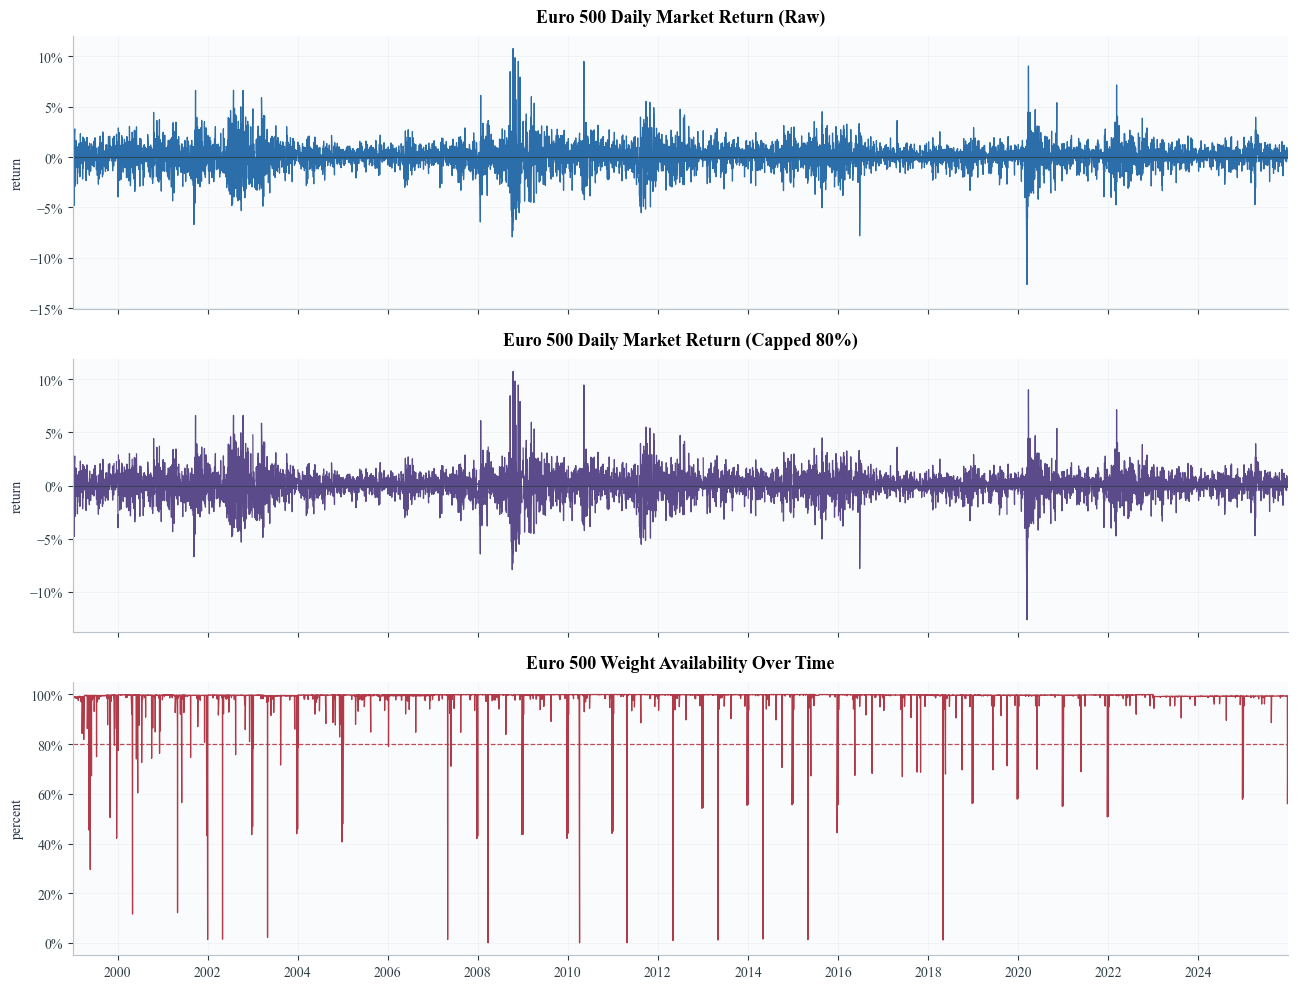

Saved Step 3 plot: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/euro500_step3_diagnostics.png


In [15]:

(TABLES_DIR := BASE_DIR / "graphs").mkdir(parents=True, exist_ok=True)

diag = market_daily_out.copy()
diag["date"] = pd.to_datetime(diag["date"], errors="coerce")
diag = diag.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

X_MIN_STEP3 = pd.Timestamp("1999-01-01")
X_MAX_STEP3 = pd.Timestamp("2025-12-31")
X_TICKS_STEP3 = pd.date_range("2000-01-01", "2024-01-01", freq="2YS")

diagnostics = {
    "obs_days": int(len(diag)),
    "start": pd.to_datetime(diag["date"].min(), errors="coerce"),
    "end": pd.to_datetime(diag["date"].max(), errors="coerce"),
    "mean_daily_return": float(diag["market_return_ffmcap"].mean()),
    "vol_daily_return": float(diag["market_return_ffmcap"].std()),
    "mean_daily_return_capped80": float(diag["market_return_ffmcap_capped80"].mean()),
    "vol_daily_return_capped80": float(diag["market_return_ffmcap_capped80"].std()),
    "mean_weight_available": float(pd.to_numeric(diag["weight_available"], errors="coerce").mean()),
}

print("Market index diagnostics:")
print(f"  obs_days: {diagnostics['obs_days']}")
print(f"  start: {diagnostics['start'].strftime('%Y-%m-%d')}")
print(f"  end: {diagnostics['end'].strftime('%Y-%m-%d')}")
print(f"  mean_daily_return: {diagnostics['mean_daily_return']*100:.2f}%")
print(f"  vol_daily_return: {diagnostics['vol_daily_return']*100:.2f}%")
print(f"  mean_daily_return_capped80: {diagnostics['mean_daily_return_capped80']*100:.2f}%")
print(f"  vol_daily_return_capped80: {diagnostics['vol_daily_return_capped80']*100:.2f}%")
print(f"  mean_weight_available: {diagnostics['mean_weight_available']*100:.2f}%")

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

axes[0].plot(diag["date"], diag["market_return_ffmcap"], lw=0.9, color=COLORS["blue"])
axes[0].axhline(0.0, color=COLORS["reference"], lw=0.8, alpha=0.7)
axes[0].set_title("Euro 500 Daily Market Return (Raw)")
axes[0].set_ylabel("return")
axes[0].set_ylim(top=0.12)

axes[1].plot(diag["date"], diag["market_return_ffmcap_capped80"], lw=0.9, color=COLORS["purple"])
axes[1].axhline(0.0, color=COLORS["reference"], lw=0.8, alpha=0.7)
axes[1].set_title("Euro 500 Daily Market Return (Capped 80%)")
axes[1].set_ylabel("return")

axes[2].plot(diag["date"], pd.to_numeric(diag["weight_available"], errors="coerce"), color=COLORS["accent"], lw=0.9)
axes[2].axhline(0.80, color=COLORS["accent"], lw=0.9, linestyle="--", alpha=0.9)
axes[2].set_title("Euro 500 Weight Availability Over Time")
axes[2].set_ylabel("percent")

axes[0].yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
axes[1].yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
axes[2].yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

for ax in axes:
    style_axes(ax, grid_axis="both", label_x=-0.04, label_y=0.5, label_pad=1)
    style_time_axis(ax, x_min=X_MIN_STEP3, x_max=X_MAX_STEP3, x_ticks=X_TICKS_STEP3, date_fmt="%Y")

step3_plot_path = TABLES_DIR / "euro500_step3_diagnostics.png"
plt.tight_layout()
plt.savefig(step3_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved Step 3 plot: {step3_plot_path}")


## 4. Benchmark Pull and Comparison (LSEG)

**Ziel**
- Abruf der Daily-Benchmarkrenditen und Aufbau eines einheitlichen Vergleichsframes.

**Methode**
- Pull über LSEG (`.STOXXR`, `.STOXX50ER`) mit Feldselektion/Fallback.
- Benchmarkserien werden mit Euro-500-Market-Returns auf `date` gemerged.

**Input**
- In-Memory: `market_daily_out`
- LSEG Data API

**Output (bearbeitet)**
- In-Memory: `cmp_df`
- Cache-Dateien unter `Project_Data/cache/benchmark_cache/`


In [6]:
def pull_index_daily_return(ric: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    """
    Pull daily benchmark returns from LSEG and choose the best available field:
    earliest valid start date, then highest number of observations.
    """
    start = pd.to_datetime(start, errors="coerce")
    end = pd.to_datetime(end, errors="coerce")
    if pd.isna(start) or pd.isna(end):
        raise ValueError(f"Invalid benchmark date bounds for {ric}: start={start}, end={end}")

    start_str = start.strftime("%Y-%m-%d")
    end_str = end.strftime("%Y-%m-%d")

    tr_fields = [
        "TR.IndexNetReturn",
        "TR.TotalReturn",
        "TR.IndexTotalReturn",
        "TR.IndexGrossReturn",
    ]
    if str(ric).strip().upper() == ".STOXXR":
        # Workspace/API diagnostics showed TRDPRC_1 has the long history (1998+).
        price_fields = ["TRDPRC_1"]
    else:
        price_fields = [
            "CLOSE",
            "TR.PriceClose",
            "TRDPRC_1",
        ]

    last_err = None
    tried = []

    def _coerce_num(s: pd.Series) -> pd.Series:
        t = s.astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False).str.strip()
        t = t.replace({"": np.nan, "None": np.nan, "nan": np.nan})
        return pd.to_numeric(t, errors="coerce")

    candidates: list[tuple[pd.Timestamp, int, pd.DataFrame]] = []

    # Try TR-like return fields first (native return if available).
    for field in tr_fields:
        tried.append(field)
        try:
            raw = ld.get_history(
                universe=[ric],
                fields=[field],
                start=start_str,
                end=end_str,
                interval="daily",
            )
            if raw is None or len(raw) == 0:
                continue

            x = raw.copy().reset_index()
            if x.empty:
                continue

            date_col = x.columns[0]
            value_candidates = [c for c in x.columns if c != date_col]
            if not value_candidates:
                continue

            best_col = None
            best_non_na = -1
            for c in value_candidates:
                non_na = int(_coerce_num(x[c]).notna().sum())
                if non_na > best_non_na:
                    best_non_na = non_na
                    best_col = c
            if best_col is None or best_non_na <= 0:
                continue

            out = pd.DataFrame({
                "date": pd.to_datetime(x[date_col], errors="coerce"),
                "value": _coerce_num(x[best_col]),
            }).dropna(subset=["date", "value"]).sort_values("date")
            if out.empty:
                continue

            max_abs = out["value"].abs().quantile(0.99)
            out["ret"] = out["value"] / 100.0 if max_abs > 1.5 else out["value"]
            out = out.dropna(subset=["ret"]).copy()
            if out.empty:
                continue

            out["ric"] = ric
            out["field_used"] = field
            out["is_total_return"] = True
            cmin = pd.to_datetime(out["date"], errors="coerce").min()
            nobs = int(out["ret"].notna().sum())
            candidates.append((cmin, -nobs, out[["date", "ric", "field_used", "is_total_return", "ret"]]))
            print(f"    field {field}: n={nobs} {cmin.date()}..{pd.to_datetime(out["date"]).max().date()}")

        except Exception as e:
            last_err = e
            continue

    # Fallback: derive returns from index levels.
    for field in price_fields:
        tried.append(field)
        try:
            raw = ld.get_history(
                universe=[ric],
                fields=[field],
                start=start_str,
                end=end_str,
                interval="daily",
            )
            if raw is None or len(raw) == 0:
                continue

            x = raw.copy().reset_index()
            if x.empty:
                continue

            date_col = x.columns[0]
            value_candidates = [c for c in x.columns if c != date_col]
            if not value_candidates:
                continue

            best_col = None
            best_non_na = -1
            for c in value_candidates:
                non_na = int(_coerce_num(x[c]).notna().sum())
                if non_na > best_non_na:
                    best_non_na = non_na
                    best_col = c
            if best_col is None or best_non_na <= 1:
                continue

            out = pd.DataFrame({
                "date": pd.to_datetime(x[date_col], errors="coerce"),
                "value": _coerce_num(x[best_col]),
            }).dropna(subset=["date", "value"]).sort_values("date")
            if len(out) <= 1:
                continue

            out["ret"] = out["value"].pct_change()
            out = out.dropna(subset=["ret"]).copy()
            if out.empty:
                continue

            out["ric"] = ric
            out["field_used"] = f"{field}->pct_change"
            out["is_total_return"] = True
            cmin = pd.to_datetime(out["date"], errors="coerce").min()
            nobs = int(out["ret"].notna().sum())
            candidates.append((cmin, -nobs, out[["date", "ric", "field_used", "is_total_return", "ret"]]))
            print(f"    field {field}: n={nobs} {cmin.date()}..{pd.to_datetime(out["date"]).max().date()}")

        except Exception as e:
            last_err = e
            continue

    if candidates:
        candidates.sort(key=lambda x: (x[0], x[1]))
        return candidates[0][2].sort_values("date").reset_index(drop=True)

    msg = f"No usable TR benchmark series for {ric}. Tried fields: {tried}"
    if last_err is not None:
        msg += f" | last error: {type(last_err).__name__}: {last_err}"
    raise ValueError(msg)


# File cache for benchmark pulls to avoid repeated LSEG requests.
BENCH_CACHE_DIR = CACHE_DATA_DIR / "benchmark_cache"
BENCH_CACHE_DIR.mkdir(parents=True, exist_ok=True)
BENCH_CACHE_SCHEMA_VERSION = "v5"


def _bench_cache_path(series_name: str, start: pd.Timestamp, end: pd.Timestamp) -> Path:
    key = str(series_name).replace(".", "_dot_").replace("/", "_")
    s = pd.to_datetime(start).strftime("%Y%m%d")
    e = pd.to_datetime(end).strftime("%Y%m%d")
    return BENCH_CACHE_DIR / f"bench_{BENCH_CACHE_SCHEMA_VERSION}_{key}_{s}_{e}.parquet"


def _pull_benchmark_best_lseg(series_name: str, ric_candidates: list[str], start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    cache_path = _bench_cache_path(series_name=series_name, start=start, end=end)
    if cache_path.exists():
        out = pd.read_parquet(cache_path)
        out["date"] = pd.to_datetime(out["date"], errors="coerce")
        out = out.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
        print(f"Cache hit: {series_name} -> {cache_path.name}")
        return out

    best = None
    tried_meta = []

    ld.open_session()
    try:
        for ric in ric_candidates:
            try:
                cur = pull_index_daily_return(ric=ric, start=start, end=end)
                if cur is None or cur.empty:
                    tried_meta.append((ric, "empty"))
                    continue

                cur = cur.dropna(subset=["date", "ret"]).sort_values("date").reset_index(drop=True)
                if cur.empty:
                    tried_meta.append((ric, "empty_after_clean"))
                    continue

                cmin = pd.to_datetime(cur["date"], errors="coerce").min()
                cmax = pd.to_datetime(cur["date"], errors="coerce").max()
                nobs = int(cur["ret"].notna().sum())
                tried_meta.append((ric, f"ok n={nobs} {cmin.date()}..{cmax.date()} field={cur['field_used'].iloc[0]}"))

                score = (cmin, -nobs)
                if (best is None) or (score < best[0]):
                    best = (score, cur)
            except Exception as e:
                tried_meta.append((ric, f"fail {type(e).__name__}: {e}"))
    finally:
        ld.close_session()

    print(f"LSEG candidates for {series_name}:")
    for ric, msg in tried_meta:
        print(f"  {ric}: {msg}")

    if best is None:
        raise ValueError(f"No usable LSEG benchmark series for {series_name}. Tried: {ric_candidates}")

    out = best[1].copy()
    out.to_parquet(cache_path, index=False)
    return out


def _resolve_benchmark_bounds(min_start: str = "1999-01-01") -> tuple[pd.Timestamp, pd.Timestamp]:
    candidates = []
    min_start_dt = pd.to_datetime(min_start).normalize()

    if "market_daily_out" in globals() and isinstance(market_daily_out, pd.DataFrame) and "date" in market_daily_out.columns:
        d = pd.to_datetime(market_daily_out["date"], errors="coerce")
        if d.notna().any():
            candidates.append((d.min(), d.max(), "market_daily_out"))

    if "returns_in_index" in globals() and isinstance(returns_in_index, pd.DataFrame) and "date" in returns_in_index.columns:
        d = pd.to_datetime(returns_in_index["date"], errors="coerce")
        if d.notna().any():
            candidates.append((d.min(), d.max(), "returns_in_index"))

    if not candidates:
        raise ValueError("Could not resolve benchmark date bounds (no valid dates in market_daily_out/returns_in_index).")

    start_dt, end_dt, src = candidates[0]
    start_dt = min(start_dt.normalize(), min_start_dt)
    print(f"Benchmark date bounds from {src} (forced min start {min_start_dt.date()}): {start_dt.date()} -> {end_dt.date()}")
    return start_dt, end_dt


start_dt, end_dt = _resolve_benchmark_bounds()

# Candidate universes: try return-index RICs first, then price-index RICs with pct_change fallback.
bench_specs = [
    {"series": "stoxx600_ret", "rics": [".STOXXR"]},
    {"series": "stoxx_euro50_ret", "rics": [".STOXX50ER"]},
]

bench_frames = []
bench_meta = []

for spec in bench_specs:
    b = _pull_benchmark_best_lseg(
        series_name=spec["series"],
        ric_candidates=spec["rics"],
        start=start_dt,
        end=end_dt,
    ).rename(columns={"ret": spec["series"]})

    if b.empty:
        raise ValueError(f"Benchmark pull returned empty frame for {spec['series']}")

    bench_meta.append(
        b[["ric", "field_used", "is_total_return"]]
        .drop_duplicates()
        .assign(series=spec["series"])
    )
    bench_frames.append(b[["date", spec["series"]]])

bench_info = pd.concat(bench_meta, ignore_index=True)
print("Benchmark fields used:")
display(bench_info)

cmp_cols = [
    "date",
    "quarter",
    "market_return_ffmcap",
    "market_return_ffmcap_capped80",
    "weight_available",
]
for c in ["rf_daily", "rf_estr_annual", "excess_market_return_ffmcap", "excess_market_return_ffmcap_capped80"]:
    if c in market_daily_out.columns:
        cmp_cols.append(c)
cmp_df = market_daily_out[cmp_cols].copy()
for bf in bench_frames:
    cmp_df = cmp_df.merge(bf, on="date", how="left")

print("Comparison frame date range:", cmp_df["date"].min(), "to", cmp_df["date"].max())
print("Missing benchmark shares:")
for c in ["stoxx600_ret", "stoxx_euro50_ret"]:
    print(f"  {c}: {cmp_df[c].isna().mean():.2%}")

display(cmp_df.head())
display(cmp_df.tail())








Benchmark date bounds from market_daily_out (forced min start 1999-01-01): 1998-01-02 -> 2025-12-31
Cache hit: stoxx600_ret -> bench_v5_stoxx600_ret_19980102_20251231.parquet
Cache hit: stoxx_euro50_ret -> bench_v5_stoxx_euro50_ret_19980102_20251231.parquet
Benchmark fields used:


,ric,field_used,is_total_return,series
0,.STOXXR,TRDPRC_1->pct_change,True,stoxx600_ret
1,.STOXX50ER,TRDPRC_1->pct_change,True,stoxx_euro50_ret


Comparison frame date range: 1998-01-02 00:00:00 to 2025-12-31 00:00:00
Missing benchmark shares:
  stoxx600_ret: 0.43%
  stoxx_euro50_ret: 0.40%


,date,quarter,market_return_ffmcap,market_return_ffmcap_capped80,weight_available,rf_daily,rf_estr_annual,excess_market_return_ffmcap,excess_market_return_ffmcap_capped80,stoxx600_ret,stoxx_euro50_ret
0,1998-01-02,1998Q1,0.027136,0.027136,0.970649,NaN,NaN,NaN,NaN,NaN,NaN
1,1998-01-05,1998Q1,0.019075,0.019075,0.963910,NaN,NaN,NaN,NaN,0.018551,NaN
2,1998-01-06,1998Q1,-0.005882,NaN,0.694494,NaN,NaN,NaN,NaN,-0.003582,-0.009840
3,1998-01-07,1998Q1,-0.004753,-0.004753,0.970215,NaN,NaN,NaN,NaN,-0.002272,-0.000961
4,1998-01-08,1998Q1,-0.011034,-0.011034,0.971234,NaN,NaN,NaN,NaN,-0.010061,-0.010098


,date,quarter,market_return_ffmcap,market_return_ffmcap_capped80,weight_available,rf_daily,rf_estr_annual,excess_market_return_ffmcap,excess_market_return_ffmcap_capped80,stoxx600_ret,stoxx_euro50_ret
7179,2025-12-23,2025Q4,0.000163,0.000163,0.993449,0.000053,0.01925,0.000110,0.000110,0.003400,0.000975
7180,2025-12-24,2025Q4,-0.000686,NaN,0.559984,0.000053,0.01926,-0.000739,NaN,-0.000054,-0.000529
7181,2025-12-29,2025Q4,0.001546,0.001546,0.993890,0.000053,0.01934,0.001493,0.001493,0.001073,0.000951
7182,2025-12-30,2025Q4,0.007105,0.007105,0.993874,0.000053,0.01930,0.007052,0.007052,0.005983,0.007739
7183,2025-12-31,2025Q4,-0.000906,NaN,0.568697,0.000053,0.01921,-0.000959,NaN,-0.000870,-0.000496


## 5. Relative Performance Views

**Ziel**
- Vergleich Euro 500 vs. Benchmarks über kumulierte Entwicklung und rollierende Outperformance.

**Methode**
- Cumulative Growth (Startwert = 1).
- Rolling 3Y **compounded** relative return:
$$
R^{rel}_{t,3Y}=\prod_{k=t-755}^{t}\frac{1+r^{Euro500}_k}{1+r^{Bench}_k}-1
$$
- Zusätzliche RF-Ansichten (daily und annualized).

**Input**
- In-Memory: `cmp_df`

**Output (bearbeitet)**
- `Project_Data/graphs/euro500_cum_growth_and_roll3y.png`
- `Project_Data/graphs/euro500_rf_daily_and_annual.png`


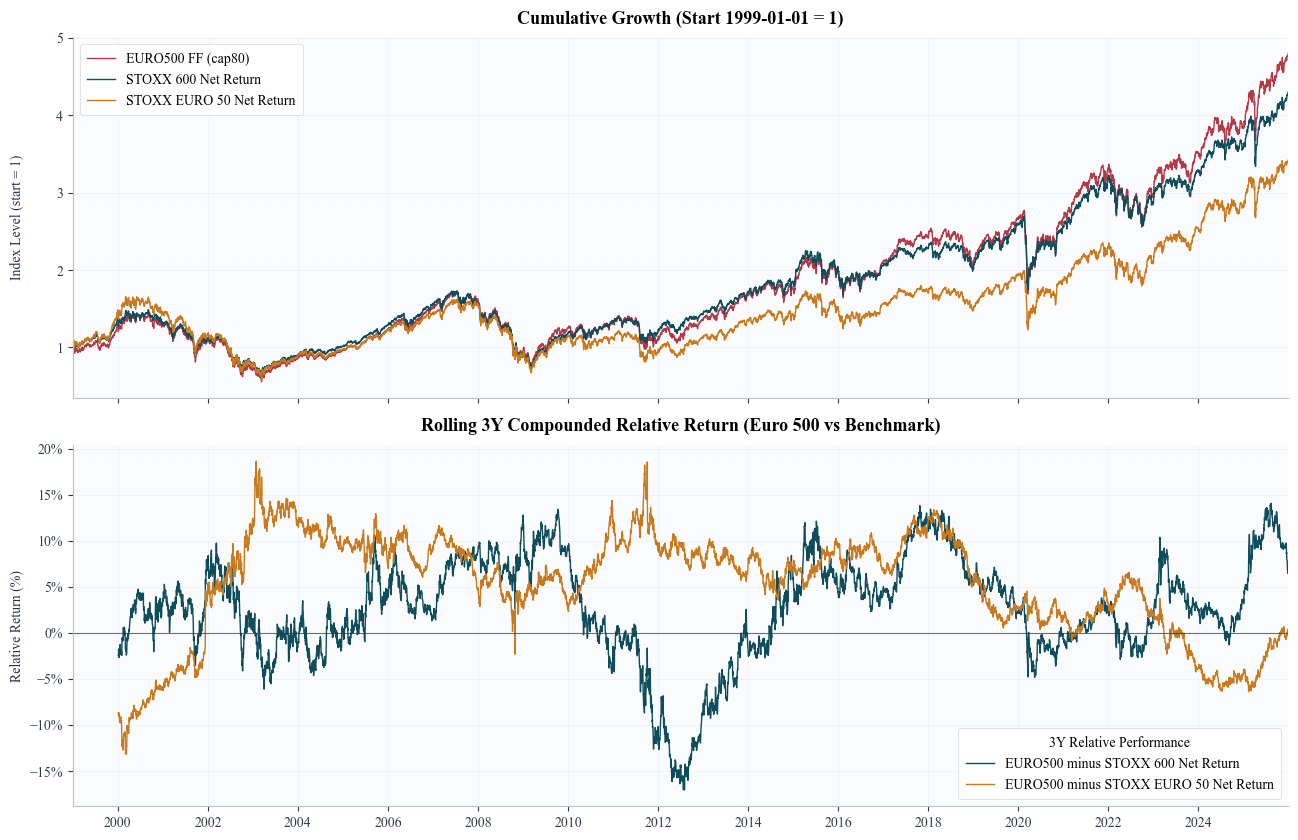

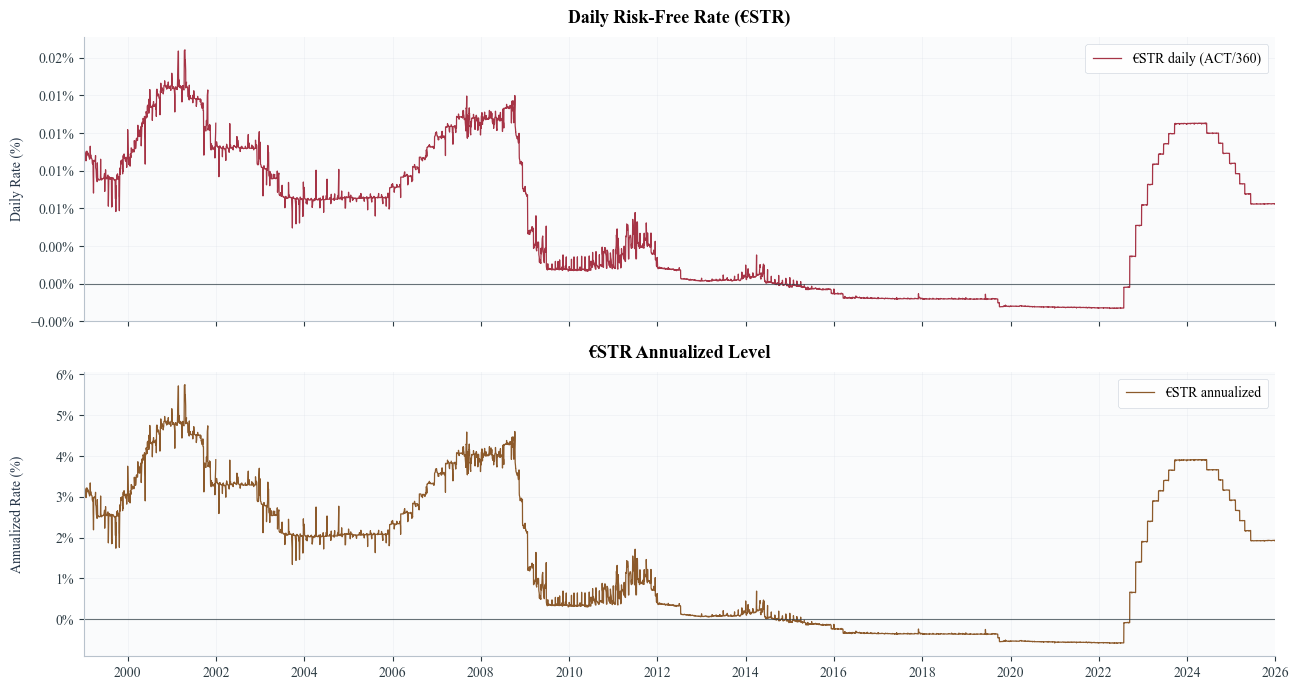

Saved RF plot: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/euro500_rf_daily_and_annual.png


In [16]:

def _normalized_cum_level(ret: pd.Series, base: float = 1.0) -> pd.Series:
    """Convert daily returns into a normalized cumulative level."""
    r = pd.to_numeric(ret, errors="coerce")
    out = (1.0 + r.fillna(0.0)).cumprod() * float(base)
    return out

(TABLES_DIR := BASE_DIR / "graphs").mkdir(parents=True, exist_ok=True)

cmp_plot = cmp_df.copy()
cmp_plot["date"] = pd.to_datetime(cmp_plot["date"], errors="coerce")
cmp_plot = cmp_plot.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

START_NORM = pd.Timestamp("1999-01-01")
cmp_norm = cmp_plot[cmp_plot["date"] >= START_NORM].copy()

series_cols = [
    "market_return_ffmcap_capped80",
    "stoxx600_ret",
    "stoxx_euro50_ret",
]
series_cols = [c for c in series_cols if c in cmp_norm.columns]

for c in series_cols:
    cmp_norm[f"lvl_{c}"] = _normalized_cum_level(cmp_norm[c])

# 3Y (756 trading days) rolling relative performance vs benchmarks
rolling_win = 756
ROLL_START = pd.Timestamp("1999-01-01")
X_MIN = pd.Timestamp("1999-01-01")
X_MAX = pd.Timestamp("2025-12-31")
X_TICKS = pd.date_range("2000-01-01", "2026-01-01", freq="2YS")
rel = cmp_plot.loc[cmp_plot["date"] >= ROLL_START, ["date", "market_return_ffmcap_capped80"]].copy()
if "stoxx600_ret" in cmp_plot.columns:
    rel["spread_vs_stoxx600"] = cmp_plot["market_return_ffmcap_capped80"] - cmp_plot["stoxx600_ret"]
if "stoxx_euro50_ret" in cmp_plot.columns:
    rel["spread_vs_euro50"] = cmp_plot["market_return_ffmcap_capped80"] - cmp_plot["stoxx_euro50_ret"]

roll = rel[["date"]].copy()
bench_col_map = {
    "spread_vs_stoxx600": "stoxx600_ret",
    "spread_vs_euro50": "stoxx_euro50_ret",
}

for c in [x for x in rel.columns if x.startswith("spread_")]:
    bench_col = bench_col_map.get(c)
    if not bench_col or bench_col not in cmp_plot.columns:
        continue

    bench_series = pd.to_numeric(cmp_plot.loc[cmp_plot["date"] >= ROLL_START, bench_col], errors="coerce")
    euro_series = pd.to_numeric(rel["market_return_ffmcap_capped80"], errors="coerce")

    rel_daily = (1.0 + euro_series) / (1.0 + bench_series) - 1.0
    rel_valid = euro_series.notna() & bench_series.notna()

    rel_growth = (1.0 + rel_daily.fillna(0.0)).rolling(rolling_win, min_periods=252).apply(np.prod, raw=True) - 1.0
    rel_growth[rel_valid.rolling(rolling_win, min_periods=1).sum() < 252] = np.nan
    roll[f"roll3y_{c}"] = rel_growth

fig, axes = plt.subplots(2, 1, figsize=(13, 8.5), sharex=True)

# Panel 1: cumulative growth
ax = axes[0]
if "lvl_market_return_ffmcap_capped80" in cmp_norm.columns:
    ax.plot(cmp_norm["date"], cmp_norm["lvl_market_return_ffmcap_capped80"], color=COLORS["accent"], label="EURO500 FF (cap80)")
if "lvl_stoxx600_ret" in cmp_norm.columns:
    ax.plot(cmp_norm["date"], cmp_norm["lvl_stoxx600_ret"], color=COLORS["primary"], label="STOXX 600 Net Return")
if "lvl_stoxx_euro50_ret" in cmp_norm.columns:
    ax.plot(cmp_norm["date"], cmp_norm["lvl_stoxx_euro50_ret"], color=COLORS["orange"], label="STOXX EURO 50 Net Return")
ax.set_title("Cumulative Growth (Start 1999-01-01 = 1)")
ax.set_ylabel("Index Level (start = 1)")
style_axes(ax, grid_axis="both", label_x=-0.04, label_y=0.5, label_pad=1)
style_legend(ax, loc="best", frameon=True)

# Panel 2: rolling 3Y relative performance
ax = axes[1]
roll_label_map = {
    "roll3y_spread_vs_stoxx600": "EURO500 minus STOXX 600 Net Return",
    "roll3y_spread_vs_euro50": "EURO500 minus STOXX EURO 50 Net Return",
}
for c in [x for x in roll.columns if x.startswith("roll3y_")]:
    ax.plot(roll["date"], roll[c], color=(COLORS["primary"] if "stoxx600" in c else COLORS["orange"]), label=roll_label_map.get(c, c.replace("roll3y_", "")))
ax.axhline(0.0, color=COLORS["reference"], lw=0.8, alpha=0.7)
ax.set_title("Rolling 3Y Compounded Relative Return (Euro 500 vs Benchmark)")
ax.set_ylabel("Relative Return (%)")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
style_axes(ax, grid_axis="both", label_x=-0.04, label_y=0.5, label_pad=1)
style_legend(ax, title="3Y Relative Performance", loc="lower right", frameon=True)

for ax in axes:
    style_time_axis(ax, x_min=X_MIN, x_max=X_MAX, x_ticks=X_TICKS, date_fmt="%Y")

combined_plot_path = TABLES_DIR / "euro500_cum_growth_and_roll3y.png"
plt.tight_layout()
plt.savefig(combined_plot_path, dpi=200, bbox_inches="tight")
plt.show()

# €STR / risk-free diagnostics
if "rf_daily" in cmp_plot.columns and cmp_plot["rf_daily"].notna().any():
    rf_plot = cmp_plot[["date", "rf_daily"]].copy()
    if "rf_estr_annual" in cmp_plot.columns:
        rf_plot["rf_estr_annual"] = cmp_plot["rf_estr_annual"]

    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

    ax = axes[0]
    ax.plot(rf_plot["date"], rf_plot["rf_daily"], lw=0.9, color=COLORS["red"], label="€STR daily (ACT/360)")
    ax.axhline(0.0, color=COLORS["reference"], lw=0.8, alpha=0.7)
    ax.set_title("Daily Risk-Free Rate (€STR)")
    ax.set_ylabel("Daily Rate (%)")
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=2))
    style_axes(ax, grid_axis="both", label_x=-0.04, label_y=0.5, label_pad=1)
    style_legend(ax, loc="best", frameon=True)

    ax = axes[1]
    if "rf_estr_annual" in rf_plot.columns and rf_plot["rf_estr_annual"].notna().any():
        ax.plot(rf_plot["date"], rf_plot["rf_estr_annual"], lw=0.9, color=COLORS["brown"], label="€STR annualized")
    ax.axhline(0.0, color=COLORS["reference"], lw=0.8, alpha=0.7)
    ax.set_title("€STR Annualized Level")
    ax.set_ylabel("Annualized Rate (%)")
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    style_axes(ax, grid_axis="both", label_x=-0.04, label_y=0.5, label_pad=1)
    style_legend(ax, loc="best", frameon=True)
    
    for ax in axes:
        ax.yaxis.set_label_coords(-0.05, 0.5)
        ax.yaxis.labelpad = 5
        ax.set_xlim(X_MIN, X_MAX)
        ax.set_xticks(X_TICKS)
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    rf_png_path = TABLES_DIR / "euro500_rf_daily_and_annual.png"
    plt.tight_layout()
    plt.savefig(rf_png_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved RF plot: {rf_png_path}")

# Yearly return spread table
annual = cmp_plot.copy()
annual["year"] = annual["date"].dt.year
ann_rows = []
for y, g in annual.groupby("year"):
    row = {"year": int(y)}
    if g["market_return_ffmcap_capped80"].notna().any():
        row["euro500_ann"] = float((1 + g["market_return_ffmcap_capped80"].fillna(0)).prod() - 1)
    if "stoxx600_ret" in g.columns and g["stoxx600_ret"].notna().any():
        row["stoxx600_ann"] = float((1 + g["stoxx600_ret"].fillna(0)).prod() - 1)
        row["spread_vs_stoxx600"] = row.get("euro500_ann", np.nan) - row["stoxx600_ann"]
    if "stoxx_euro50_ret" in g.columns and g["stoxx_euro50_ret"].notna().any():
        row["stoxx_euro50_ann"] = float((1 + g["stoxx_euro50_ret"].fillna(0)).prod() - 1)
        row["spread_vs_euro50"] = row.get("euro500_ann", np.nan) - row["stoxx_euro50_ann"]
    ann_rows.append(row)

annual_spread = pd.DataFrame(ann_rows).sort_values("year").reset_index(drop=True)


## 6. Daily Rolling CAPM Beta

**Ziel**
- Schätzung eines täglichen, firmenspezifischen CAPM-Betas als zeitvariierendes Risiko-Maß.

**Methode**
- Rolling-Fenster mit `BETA_WINDOW = 252`, `BETA_MIN_OBS = 126`.
- Marktserie: `market_return_ffmcap_capped80`.

**Input**
- `Project_Data/intermediate/daily_returns_company_all.parquet`
- `Project_Data/intermediate/euro500_daily_returns.parquet`
- `Project_Data/intermediate/euro500_index_returns.parquet` (Fallback für Marktserie)

**Output (bearbeitet)**
- `Project_Data/intermediate/daily_returns_company_all.parquet` (inkl. `beta`)
- `Project_Data/intermediate/euro500_daily_returns.parquet` (inkl. gemergtem `beta`)
- `Project_Data/intermediate/euro500.parquet` (beta per `firm_id` + `date`)


### 6A. Methodik und QC-Regeln der Beta-Schätzung

**Formel**
$$
\beta_{i,t}=\frac{\operatorname{Cov}_W(r_i,r_m)}{\operatorname{Var}_W(r_m)}
$$
mit
$$
\operatorname{Cov}_W(r_i,r_m)=E_W[r_i r_m]-E_W[r_i]E_W[r_m],
\quad
\operatorname{Var}_W(r_m)=E_W[r_m^2]-E_W[r_m]^2
$$

**Definitionen**
- `r_i`: tägliche Firmenrendite (`ret`)
- `r_m`: tägliche Marktrendite (`market_ret_cap80`)
- `W`: rollendes Fenster (252 Handelstage, mind. 126 Beobachtungen)

**QC-Regeln**
- `n_firms_day >= 300`
- `var_m_roll >= 1e-6`
- `|beta_capm_daily| <= 3`

Verletzungen werden als `NaN` markiert (keine Zeilenlöschung).


In [12]:
MARKET_COL = "market_return_ffmcap_capped80"
BETA_WINDOW = 252
BETA_MIN_OBS = 160
EWMA_HALFLIFE = 63

# QC parameter
MIN_FIRMS_DAY = 300
MIN_VAR_M_ROLL = 1e-6
MAX_ABS_BETA = 3.0

# Data-quality parameter
MAX_ABS_RET = 0.60
MAX_ABS_MKT_RET = 0.20
STALE_WINDOW = 20
STALE_ZERO_SHARE_MAX = 0.90
ILLIQ_WINDOW = 60
ILLIQ_MIN_ACTIVE_SHARE = 0.25   # >=15 aktive Tage in 60
RET_MOVE_EPS = 1e-4

# Shrinkage parameter (Blume-style towards 1)
SHRINK_TO_ONE = 0.67

# Robust mix parameter
WEIGHT_SW = 0.60
WEIGHT_EWMA = 0.40

RETURNS_ALL_PATH = DATA_DIR / "daily_returns_company_all.parquet"
OUTPUT_DAILY_RETURNS_EURO500 = globals().get("RETURNS_IN_INDEX_PATH", DATA_DIR / "euro500_daily_returns.parquet")
MARKET_RETURNS_PATH = DATA_DIR / "euro500_index_returns.parquet"

# Prefer in-memory market series from this notebook; fallback to parquet file.
if "market_daily_out" in locals() and isinstance(market_daily_out, pd.DataFrame):
    market_src = market_daily_out.copy()
elif MARKET_RETURNS_PATH.exists():
    market_src = pd.read_parquet(MARKET_RETURNS_PATH).copy()
else:
    raise FileNotFoundError(
        f"No market series found. Run Step 2 first or provide file: {MARKET_RETURNS_PATH}"
    )

if MARKET_COL not in market_src.columns:
    raise ValueError(f"Missing market column: {MARKET_COL}")

if not RETURNS_ALL_PATH.exists():
    raise FileNotFoundError(f"File not found: {RETURNS_ALL_PATH}")


# ---------- helper ----------
def _build_firm_id(df: pd.DataFrame) -> pd.Series:
    out = pd.Series(pd.NA, index=df.index, dtype="string")

    if "ISIN" in df.columns:
        v = df["ISIN"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        out = out.fillna("ISIN:" + v)

    if "RIC_current" in df.columns:
        v = df["RIC_current"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        out = out.fillna("RIC:" + v)

    if "RIC" in df.columns:
        v = df["RIC"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        out = out.fillna("RIC:" + v)

    if "SEDOL" in df.columns:
        v = df["SEDOL"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        out = out.fillna("SEDOL:" + v)

    return out


def _ewm_mean_by_firm(s: pd.Series, halflife: int, min_periods: int) -> pd.Series:
    return s.groupby(returns_all["firm_id"], sort=False).transform(
        lambda x: x.ewm(halflife=halflife, min_periods=min_periods, adjust=False).mean()
    )


# ---------- 1) beta on full daily panel ----------
returns_all = pd.read_parquet(RETURNS_ALL_PATH).copy()
returns_all_orig_cols = list(returns_all.columns)

returns_all["date"] = pd.to_datetime(returns_all["date"], errors="coerce")
returns_all["ret"] = pd.to_numeric(returns_all["ret"], errors="coerce")

if "firm_id" in returns_all.columns:
    returns_all["firm_id"] = returns_all["firm_id"].astype("string").str.strip()
    returns_all.loc[returns_all["firm_id"] == "", "firm_id"] = pd.NA
    returns_all["firm_id"] = returns_all["firm_id"].fillna(_build_firm_id(returns_all))
else:
    returns_all["firm_id"] = _build_firm_id(returns_all)

market_daily = market_src[["date", MARKET_COL]].copy()
market_daily["date"] = pd.to_datetime(market_daily["date"], errors="coerce")
market_daily["market_ret_cap80"] = pd.to_numeric(market_daily[MARKET_COL], errors="coerce")
market_daily = market_daily[["date", "market_ret_cap80"]].drop_duplicates(subset=["date"]).sort_values("date")
market_daily["market_ret_lag1"] = market_daily["market_ret_cap80"].shift(1)
market_daily["market_ret_lead1"] = market_daily["market_ret_cap80"].shift(-1)

all_raw = len(returns_all)
returns_all = (
    returns_all
    .dropna(subset=["date", "firm_id"])
    .sort_values(["firm_id", "date"], kind="mergesort")
    .drop_duplicates(subset=["firm_id", "date"], keep="last")
    .reset_index(drop=True)
)

# Avoid column-name collisions from prior runs.
for c in [
    "market_ret_cap80", "market_ret_cap80_x", "market_ret_cap80_y",
    "market_ret_lag1", "market_ret_lead1",
]:
    if c in returns_all.columns:
        returns_all = returns_all.drop(columns=[c])

returns_all = returns_all.merge(market_daily, on="date", how="left", validate="m:1")

if "market_ret_cap80" not in returns_all.columns:
    raise KeyError("market_ret_cap80 missing after merge with market_daily")

# --- hard data-quality filters ---
returns_all["ret_abs"] = returns_all["ret"].abs()
returns_all["mkt_abs"] = returns_all["market_ret_cap80"].abs()

valid_base = (
    returns_all["ret"].notna()
    & returns_all["market_ret_cap80"].notna()
    & (returns_all["ret_abs"] <= MAX_ABS_RET)
    & (returns_all["mkt_abs"] <= MAX_ABS_MKT_RET)
)

g = returns_all.groupby("firm_id", group_keys=False, sort=False)
returns_all["is_zero_ret"] = (returns_all["ret_abs"] <= 1e-12).astype(float)
returns_all["is_active_ret"] = (returns_all["ret_abs"] >= RET_MOVE_EPS).astype(float)

zero_share = (
    g["is_zero_ret"]
    .rolling(STALE_WINDOW, min_periods=max(5, STALE_WINDOW // 2))
    .mean()
    .reset_index(level=0, drop=True)
)
active_share = (
    g["is_active_ret"]
    .rolling(ILLIQ_WINDOW, min_periods=max(20, ILLIQ_WINDOW // 2))
    .mean()
    .reset_index(level=0, drop=True)
)

returns_all["zero_share_stale"] = zero_share
returns_all["active_share_illiquid"] = active_share

quality_ok = (
    valid_base
    & (returns_all["zero_share_stale"].fillna(1.0) <= STALE_ZERO_SHARE_MAX)
    & (returns_all["active_share_illiquid"].fillna(0.0) >= ILLIQ_MIN_ACTIVE_SHARE)
)
returns_all["quality_ok"] = quality_ok

returns_all["qret"] = returns_all["ret"].where(quality_ok, np.nan)
returns_all["qmkt"] = returns_all["market_ret_cap80"].where(quality_ok, np.nan)
returns_all["qmkt_lag1"] = returns_all["market_ret_lag1"].where(quality_ok, np.nan)
returns_all["qmkt_lead1"] = returns_all["market_ret_lead1"].where(quality_ok, np.nan)

# --- rolling moments for SW / OLS beta ---
returns_all["qret_x_m0"] = returns_all["qret"] * returns_all["qmkt"]
returns_all["qret_x_mlag"] = returns_all["qret"] * returns_all["qmkt_lag1"]
returns_all["qret_x_mlead"] = returns_all["qret"] * returns_all["qmkt_lead1"]
returns_all["qmkt_sq"] = returns_all["qmkt"] ** 2
returns_all["qmkt_x_lag"] = returns_all["qmkt"] * returns_all["qmkt_lag1"]

obs_roll = g["qret"].rolling(BETA_WINDOW, min_periods=1).count().reset_index(level=0, drop=True)
mean_i = g["qret"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_m = g["qmkt"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_mlag = g["qmkt_lag1"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_mlead = g["qmkt_lead1"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_im0 = g["qret_x_m0"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_imlag = g["qret_x_mlag"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_imlead = g["qret_x_mlead"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_m2 = g["qmkt_sq"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_mmlag = g["qmkt_x_lag"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)

cov_im0 = mean_im0 - (mean_i * mean_m)
cov_imlag = mean_imlag - (mean_i * mean_mlag)
cov_imlead = mean_imlead - (mean_i * mean_mlead)
var_m = mean_m2 - (mean_m ** 2)
cov_m_lag = mean_mmlag - (mean_m * mean_mlag)

beta_ols = np.where(var_m > 0, cov_im0 / var_m, np.nan)
den_sw = var_m + 2.0 * cov_m_lag
beta_sw = np.where(den_sw > 0, (cov_imlag + cov_im0 + cov_imlead) / den_sw, np.nan)

# --- EWMA fallback/stabilizer ---
ewm_i = _ewm_mean_by_firm(returns_all["qret"], EWMA_HALFLIFE, BETA_MIN_OBS)
ewm_m = _ewm_mean_by_firm(returns_all["qmkt"], EWMA_HALFLIFE, BETA_MIN_OBS)
ewm_im0 = _ewm_mean_by_firm(returns_all["qret_x_m0"], EWMA_HALFLIFE, BETA_MIN_OBS)
ewm_m2 = _ewm_mean_by_firm(returns_all["qmkt_sq"], EWMA_HALFLIFE, BETA_MIN_OBS)

cov_ewm = ewm_im0 - (ewm_i * ewm_m)
var_ewm = ewm_m2 - (ewm_m ** 2)
beta_ewm = np.where(var_ewm > 0, cov_ewm / var_ewm, np.nan)

beta_sw_s = pd.Series(beta_sw, index=returns_all.index, dtype="float64")
beta_ols_s = pd.Series(beta_ols, index=returns_all.index, dtype="float64")
beta_ewm_s = pd.Series(beta_ewm, index=returns_all.index, dtype="float64")

beta_struct = beta_sw_s.combine_first(beta_ols_s)
beta_robust = (WEIGHT_SW * beta_struct) + (WEIGHT_EWMA * beta_ewm_s)
beta_robust = beta_robust.where(beta_struct.notna() | beta_ewm_s.notna(), np.nan)

# Blume-style shrinkage toward market beta 1
beta_shrunk = (SHRINK_TO_ONE * beta_robust) + ((1.0 - SHRINK_TO_ONE) * 1.0)

returns_all["var_m_roll"] = var_m
returns_all["obs_roll"] = obs_roll
returns_all["beta_ols_raw"] = beta_ols_s
returns_all["beta_sw_raw"] = beta_sw_s
returns_all["beta_ewma_raw"] = beta_ewm_s
returns_all["beta_pre_shrink"] = beta_robust
returns_all["beta_capm_daily"] = beta_shrunk

n_firms_day = (
    returns_all.groupby("date", as_index=False)["firm_id"]
    .nunique()
    .rename(columns={"firm_id": "n_firms_day"})
)
returns_all = returns_all.merge(n_firms_day, on="date", how="left")

qc_ok = (
    returns_all["quality_ok"]
    & (returns_all["obs_roll"] >= BETA_MIN_OBS)
    & (returns_all["n_firms_day"] >= MIN_FIRMS_DAY)
    & (returns_all["var_m_roll"] >= MIN_VAR_M_ROLL)
    & (returns_all["beta_capm_daily"].abs() <= MAX_ABS_BETA)
)
returns_all["beta_capm_daily"] = returns_all["beta_capm_daily"].where(qc_ok, np.nan)
returns_all["beta"] = pd.to_numeric(returns_all["beta_capm_daily"], errors="coerce")

all_keep_cols = returns_all_orig_cols.copy()
for c in ["market_ret_cap80", "beta"]:
    if c not in all_keep_cols:
        all_keep_cols.append(c)
returns_all_out = returns_all[all_keep_cols].copy()
returns_all_out.to_parquet(RETURNS_ALL_PATH, index=False)

full_beta_share = float(returns_all_out["beta"].notna().mean())


# ---------- 2) merge beta to in-index daily panel ----------
if "returns_in_index" in locals() and isinstance(returns_in_index, pd.DataFrame):
    daily_in = returns_in_index.copy()
else:
    if not Path(OUTPUT_DAILY_RETURNS_EURO500).exists():
        raise FileNotFoundError(f"File not found: {OUTPUT_DAILY_RETURNS_EURO500}. Run Step 2 first.")
    daily_in = pd.read_parquet(OUTPUT_DAILY_RETURNS_EURO500).copy()

daily_in["date"] = pd.to_datetime(daily_in["date"], errors="coerce")
daily_in["ret"] = pd.to_numeric(daily_in["ret"], errors="coerce")

if "firm_id" in daily_in.columns:
    daily_in["firm_id"] = daily_in["firm_id"].astype("string").str.strip()
    daily_in.loc[daily_in["firm_id"] == "", "firm_id"] = pd.NA
    daily_in["firm_id"] = daily_in["firm_id"].fillna(_build_firm_id(daily_in))
else:
    daily_in["firm_id"] = _build_firm_id(daily_in)

before_dups_in = len(daily_in)
daily_in = (
    daily_in
    .dropna(subset=["date", "firm_id"])
    .sort_values(["firm_id", "date"], kind="mergesort")
    .drop_duplicates(subset=["firm_id", "date"], keep="last")
    .reset_index(drop=True)
)

beta_map = (
    returns_all_out[["date", "firm_id", "market_ret_cap80", "beta"]]
    .dropna(subset=["date", "firm_id"])
    .drop_duplicates(subset=["date", "firm_id"], keep="last")
    .rename(columns={"market_ret_cap80": "market_ret_cap80_from_all", "beta": "beta_from_all"})
)

daily_in = daily_in.merge(beta_map, on=["date", "firm_id"], how="left")

old_beta = pd.to_numeric(daily_in["beta"], errors="coerce") if "beta" in daily_in.columns else pd.Series(np.nan, index=daily_in.index)
daily_in["beta"] = pd.to_numeric(daily_in["beta_from_all"], errors="coerce").combine_first(old_beta)

old_mkt = pd.to_numeric(daily_in["market_ret_cap80"], errors="coerce") if "market_ret_cap80" in daily_in.columns else pd.Series(np.nan, index=daily_in.index)
daily_in["market_ret_cap80"] = pd.to_numeric(daily_in["market_ret_cap80_from_all"], errors="coerce").combine_first(old_mkt)

daily_in = daily_in.drop(columns=[c for c in ["beta_from_all", "market_ret_cap80_from_all"] if c in daily_in.columns])

# Keep in-memory frame consistent for downstream notebook cells.
returns_in_index = daily_in.copy()
daily_company_data = daily_in.copy()

daily_company_data.to_parquet(OUTPUT_DAILY_RETURNS_EURO500, index=False)

in_index_beta_share = float(daily_company_data["beta"].notna().mean())
date_min = pd.to_datetime(daily_company_data["date"], errors="coerce").min()
date_max = pd.to_datetime(daily_company_data["date"], errors="coerce").max()

# Coverage focus window requested for reporting.
COV_START = pd.Timestamp("1999-01-01")
COV_END = pd.Timestamp("2025-12-31")
cov_mask = daily_company_data["date"].between(COV_START, COV_END, inclusive="both")
cov_df = daily_company_data.loc[cov_mask].copy()
coverage_rate = cov_df["beta"].notna().mean() if len(cov_df) > 0 else np.nan

coverage_days = int(cov_df["date"].nunique())
coverage_rows = int(len(cov_df))


# ---------- 3) attach latest beta to euro500 (as-of) ----------
BETA_ATTACH_TOL_DAYS = 20


def _clean_id(s: pd.Series) -> pd.Series:
    x = s.astype("string").str.strip()
    return x.where(x.notna() & (x != ""), pd.NA)


euro500_upd = euro500.copy() if "euro500" in locals() else pd.read_parquet(EURO500_PATH).copy()

if "date" not in euro500_upd.columns:
    raise ValueError("euro500 is missing 'date' column; cannot map beta by date.")

euro500_upd["date"] = pd.to_datetime(euro500_upd["date"], errors="coerce").dt.normalize()
# User preference: do not keep/use asof_date; always use date as the benchmark date.
if "asof_date" in euro500_upd.columns:
    euro500_upd = euro500_upd.drop(columns=["asof_date"])

if "firm_id" not in euro500_upd.columns:
    fid = pd.Series(pd.NA, index=euro500_upd.index, dtype="string")
    if "ISIN" in euro500_upd.columns:
        fid = fid.fillna("ISIN:" + _clean_id(euro500_upd["ISIN"]))
    if "RIC_current" in euro500_upd.columns:
        fid = fid.fillna("RIC:" + _clean_id(euro500_upd["RIC_current"]))
    if "RIC" in euro500_upd.columns:
        fid = fid.fillna("RIC:" + _clean_id(euro500_upd["RIC"]))
    euro500_upd["firm_id"] = fid
else:
    euro500_upd["firm_id"] = _clean_id(euro500_upd["firm_id"])

beta_src = daily_company_data[["date", "beta", "firm_id"]].copy()
beta_src["date"] = pd.to_datetime(beta_src["date"], errors="coerce").dt.normalize()
beta_src["beta"] = pd.to_numeric(beta_src["beta"], errors="coerce")
beta_src["firm_id"] = _clean_id(beta_src["firm_id"])


def _map_beta_by_date(req_df: pd.DataFrame, beta_df: pd.DataFrame, id_col: str, out_col: str) -> pd.DataFrame:
    req_df = req_df.dropna(subset=[id_col, "date"]).copy()
    beta_df = beta_df.dropna(subset=[id_col, "date"]).copy()
    if req_df.empty or beta_df.empty:
        return pd.DataFrame(columns=[id_col, "date", out_col])

    req_df = req_df[[id_col, "date"]].drop_duplicates([id_col, "date"], keep="last")
    beta_df = beta_df[[id_col, "date", "beta"]].drop_duplicates([id_col, "date"], keep="last")

    req_df = req_df.sort_values(["date", id_col], kind="mergesort")
    beta_df = beta_df.sort_values(["date", id_col], kind="mergesort")

    out = pd.merge_asof(
        req_df,
        beta_df,
        left_on="date",
        right_on="date",
        by=id_col,
        direction="backward",
        tolerance=pd.Timedelta(days=BETA_ATTACH_TOL_DAYS),
    )
    return out.rename(columns={"beta": out_col})[[id_col, "date", out_col]]


req_firm = euro500_upd[["firm_id", "date"]].copy()
beta_firm = beta_src[["firm_id", "date", "beta"]].copy()
map_firm = _map_beta_by_date(req_firm, beta_firm, id_col="firm_id", out_col="beta_firm")

euro500_upd = euro500_upd.merge(map_firm, on=["firm_id", "date"], how="left")

old_beta = pd.to_numeric(euro500_upd["beta"], errors="coerce") if "beta" in euro500_upd.columns else pd.Series(np.nan, index=euro500_upd.index)
firm_beta = pd.to_numeric(euro500_upd["beta_firm"], errors="coerce") if "beta_firm" in euro500_upd.columns else pd.Series(np.nan, index=euro500_upd.index)
euro500_upd["beta"] = firm_beta.combine_first(old_beta)

euro500_upd = euro500_upd.drop(columns=[c for c in ["beta_firm"] if c in euro500_upd.columns], errors="ignore")
euro500_upd.to_parquet(EURO500_PATH, index=False)
euro500 = euro500_upd.copy()

quarterly_mask = euro500_upd["date"].between(COV_START, COV_END, inclusive="both")
quarterly_df = euro500_upd.loc[quarterly_mask].copy()
quarterly_beta_coverage = quarterly_df["beta"].notna().mean() if len(quarterly_df) > 0 else np.nan

print("Beta Summary")
print(f"- input rows (all daily): {all_raw:,} -> {len(returns_all):,}")
print(f"- in-index rows: {before_dups_in:,} -> {len(daily_company_data):,}")
print(f"- beta coverage (full panel daily): {full_beta_share*100:.2f}%")
print(f"- beta coverage (in-index daily): {in_index_beta_share*100:.2f}%")
print(f"- quality-ok share (full panel): {returns_all['quality_ok'].mean()*100:.2f}%")
if pd.notna(coverage_rate):
    print(f"- beta coverage ({COV_START:%Y-%m-%d} to {COV_END:%Y-%m-%d} daily): {coverage_rate*100:.2f}%")
else:
    print(f"- beta coverage ({COV_START:%Y-%m-%d} to {COV_END:%Y-%m-%d} daily): n/a")
if pd.notna(quarterly_beta_coverage):
    print(f"- beta coverage (quarterly index {COV_START:%Y} to {COV_END:%Y}): {quarterly_beta_coverage*100:.2f}%")
else:
    print(f"- beta coverage (quarterly index {COV_START:%Y} to {COV_END:%Y}): n/a")
print(f"- coverage window: {coverage_rows:,} rows | {coverage_days:,} days")



KeyboardInterrupt: 

### 6B. Diagnose der Beta-Qualität

**Ziel**
- Plausibilitäts- und Stabilitätsprüfung der geschätzten Beta-Reihe.

**Methode (aktualisiert)**
- Schätzung: Rolling Scholes-Williams-Beta (Lead/Lag-Korrektur) mit OLS-Fallback.
- Stabilisierung: EWMA-Momente (`EWMA_HALFLIFE = 63`) und robuster Mix (`0.60 * SW + 0.40 * EWMA`).
- Shrinkage: Blume-artig Richtung 1 (`SHRINK_TO_ONE = 0.67`).
- Beobachtungsfenster: `BETA_WINDOW = 252`, Mindestbeobachtungen `BETA_MIN_OBS = 160`.
- Quality-Gates:
  - Return-Caps (`MAX_ABS_RET = 0.60`, `MAX_ABS_MKT_RET = 0.20`)
  - Stale-Filter (`STALE_WINDOW = 20`, `STALE_ZERO_SHARE_MAX = 0.90`)
  - Illiquid-Filter (`ILLIQ_WINDOW = 60`, `ILLIQ_MIN_ACTIVE_SHARE = 0.25`)
  - Tages-Cross-Section und Marktvarianz (`MIN_FIRMS_DAY = 300`, `MIN_VAR_M_ROLL = 1e-6`)
  - Outlier-Cap (`MAX_ABS_BETA = 3.0`)
- Diagnoseplots: Median-Beta, Quantilband, Median-`R²`, Verteilungsplot (inkl. Referenz bei `beta=1` und Median-Linie).

**Input**
- In-Memory: `daily_company_data` / `analysis_df`

**Output (bearbeitet)**
- Diagnostische Plots im Notebook.
- Zusätzliche QC-Metrik in Step 6A Output: `quality-ok share (full panel)`.



In [9]:
analysis_df = daily_company_data.copy()
analysis_df = analysis_df.sort_values(["firm_id", "date"]).reset_index(drop=True)

analysis_df["ret"] = pd.to_numeric(analysis_df["ret"], errors="coerce")
analysis_df["market_ret_cap80"] = pd.to_numeric(analysis_df["market_ret_cap80"], errors="coerce")
analysis_df["beta"] = pd.to_numeric(analysis_df["beta"], errors="coerce")

# Implied fit quality: R² aus rolling corr² (pro Firma, selbes Fenster wie Beta).
analysis_df["ret_sq"] = analysis_df["ret"] ** 2
analysis_df["ret_x_m"] = analysis_df["ret"] * analysis_df["market_ret_cap80"]
analysis_df["mkt_sq"] = analysis_df["market_ret_cap80"] ** 2

g = analysis_df.groupby("firm_id", group_keys=False, sort=False)
mean_i = g["ret"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_m = g["market_ret_cap80"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_i2 = g["ret_sq"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_m2 = g["mkt_sq"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_im = g["ret_x_m"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)

cov_im = mean_im - (mean_i * mean_m)
var_i = mean_i2 - (mean_i ** 2)
var_m = mean_m2 - (mean_m ** 2)
den = np.sqrt(var_i * var_m)
corr_im = np.where(den > 0, cov_im / den, np.nan)
analysis_df["r2_capm_daily"] = np.clip(corr_im ** 2, 0, 1)

analysis_df["ret_hat"] = analysis_df["beta"] * analysis_df["market_ret_cap80"]
analysis_df["resid"] = analysis_df["ret"] - analysis_df["ret_hat"]
analysis_df["abs_err"] = (analysis_df["resid"]).abs()

n_firms_day = (
    analysis_df.groupby("date", as_index=False)["firm_id"]
    .nunique()
    .rename(columns={"firm_id": "n_firms_day"})
)
analysis_df = analysis_df.merge(n_firms_day, on="date", how="left")

summary = pd.DataFrame([
    {
        "rows": len(analysis_df),
        "companies": analysis_df["firm_id"].nunique(),
        "beta_non_null_share": analysis_df["beta"].notna().mean(),
        "r2_non_null_share": analysis_df["r2_capm_daily"].notna().mean(),
        "beta_median": analysis_df["beta"].median(),
        "beta_p10": analysis_df["beta"].quantile(0.10),
        "beta_p90": analysis_df["beta"].quantile(0.90),
        "r2_median": analysis_df["r2_capm_daily"].median(),
        "r2_p90": analysis_df["r2_capm_daily"].quantile(0.90),
        "mae": analysis_df["abs_err"].mean(),
    }
])

print("Gesamt-Diagnostik:")
display(summary)

by_company = (
    analysis_df.groupby("firm_id", as_index=False)
    .agg(
        n_obs=("beta", "size"),
        beta_non_null=("beta", lambda s: s.notna().sum()),
        beta_median=("beta", "median"),
        beta_std=("beta", "std"),
        r2_median=("r2_capm_daily", "median"),
        mae=("abs_err", "mean"),
    )
)
by_company["beta_availability"] = np.where(by_company["n_obs"] > 0, by_company["beta_non_null"] / by_company["n_obs"], np.nan)

print("Schwächste 10 Firmen nach medianem R²:")
display(by_company.sort_values(["r2_median", "beta_availability"]).head(10))

print("Stabilste 10 Firmen (hohes R², hohe Verfügbarkeit):")
display(by_company.sort_values(["r2_median", "beta_availability"], ascending=[False, False]).head(10))


Gesamt-Diagnostik:


,rows,companies,beta_non_null_share,r2_non_null_share,beta_median,beta_p10,beta_p90,r2_median,r2_p90,mae
0,3456889,1213,0.942748,0.946356,0.855251,0.480406,1.266468,0.201532,0.514802,0.012827


Schwächste 10 Firmen nach medianem R²:


,firm_id,n_obs,beta_non_null,beta_median,beta_std,r2_median,mae,beta_availability
420,FIRM0000461,170,0,NaN,NaN,0.000015,<NA>,0.000000
197,FIRM0000219,178,17,0.511342,0.013302,0.000020,0.025117,0.095506
94,FIRM0000109,424,259,0.290583,0.039435,0.000096,0.028357,0.610849
435,FIRM0000479,248,86,0.538422,0.078517,0.000108,0.044776,0.346774
210,FIRM0000233,496,329,0.337887,0.127031,0.000131,0.018103,0.663306
415,FIRM0000455,263,99,0.534766,0.033722,0.000145,0.022077,0.376426
424,FIRM0000466,256,92,0.390242,0.017971,0.000178,0.012238,0.359375
1121,FIRM0002542,190,97,0.320418,0.026706,0.000188,0.009718,0.510526
621,FIRM0000723,310,254,0.431760,0.070393,0.000201,0.010408,0.819355
138,FIRM0000156,230,66,0.374873,0.035397,0.000231,0.024769,0.286957


Stabilste 10 Firmen (hohes R², hohe Verfügbarkeit):


,firm_id,n_obs,beta_non_null,beta_median,beta_std,r2_median,mae,beta_availability
1063,FIRM0002481,7153,6927,1.287220,0.236292,0.692542,0.008948,0.968405
1061,FIRM0002478,7045,6927,1.104286,0.188354,0.655397,0.007904,0.983251
394,FIRM0000433,7045,6927,1.149259,0.169205,0.635825,0.008375,0.983251
1064,FIRM0002482,7111,6906,1.200808,0.163046,0.631227,0.00943,0.971171
1072,FIRM0002490,7152,6926,1.205391,0.203353,0.624359,0.009846,0.968400
1094,FIRM0002512,7158,6923,1.272747,0.292163,0.623520,0.010373,0.967170
1111,FIRM0002532,7111,6906,1.178560,0.178821,0.621296,0.009619,0.971171
1099,FIRM0002517,7150,6921,0.876272,0.112101,0.616382,0.006367,0.967972
1114,FIRM0002535,7151,6925,1.291068,0.256398,0.591653,0.011633,0.968396
283,FIRM0000312,7153,6927,1.058304,0.154352,0.573577,0.009085,0.968405


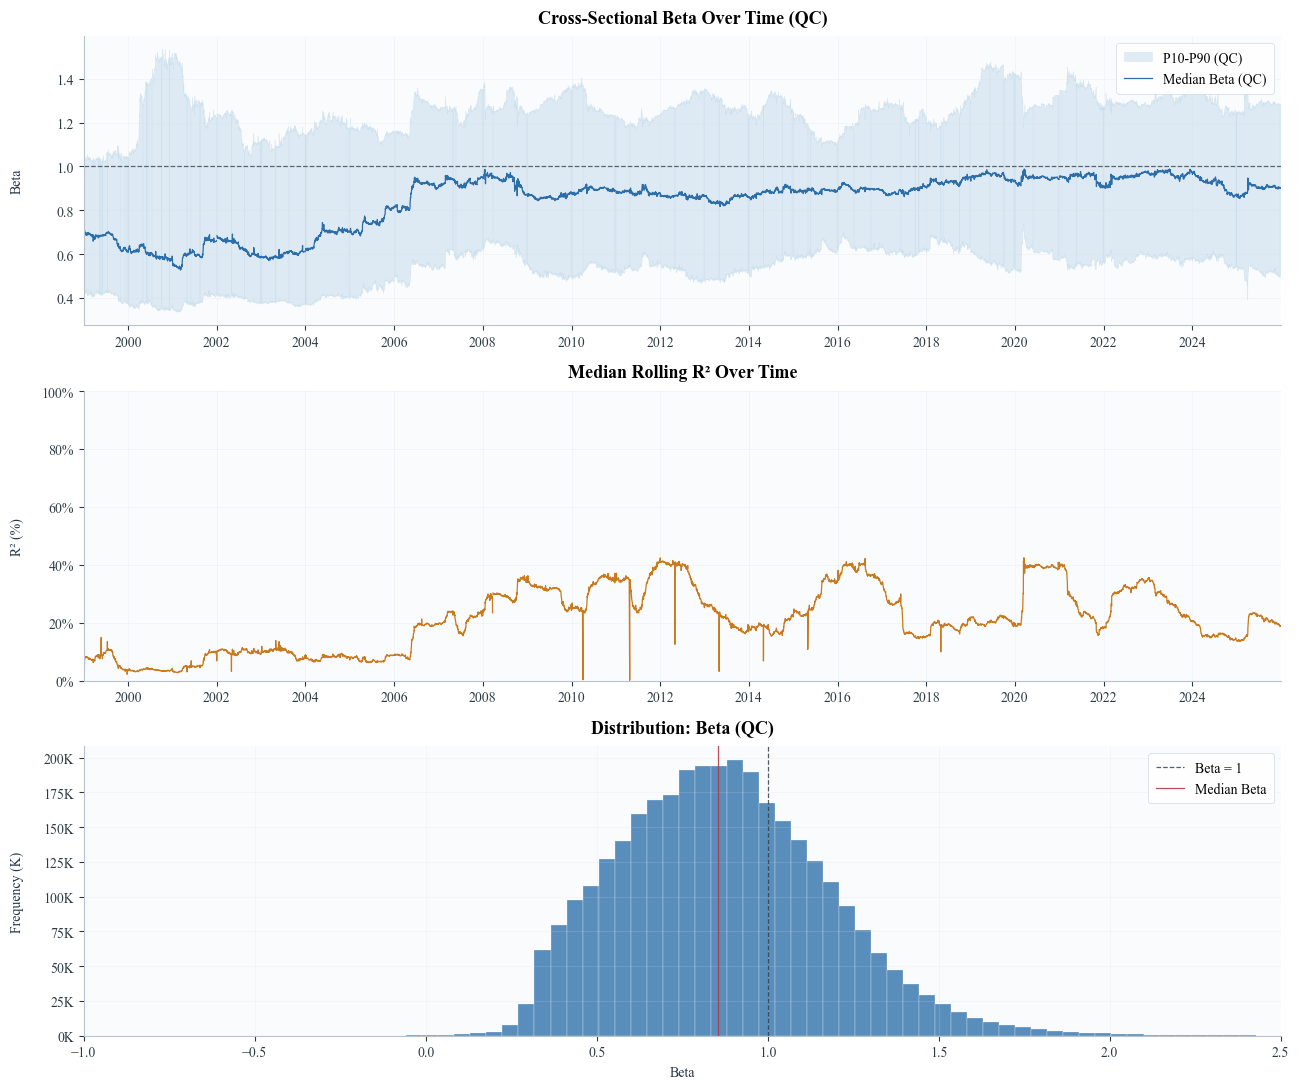

In [10]:
plot_df = analysis_df.dropna(subset=["date"]).copy()
plot_df["date"] = pd.to_datetime(plot_df["date"], errors="coerce")
plot_df = plot_df.dropna(subset=["date"]).sort_values("date")

beta_daily_stats = (
    plot_df.groupby("date", as_index=False)
    .agg(
        beta_median=("beta", "median"),
        beta_p10=("beta", lambda s: s.quantile(0.10)),
        beta_p90=("beta", lambda s: s.quantile(0.90)),
        r2_median=("r2_capm_daily", "median"),
    )
    .sort_values("date")
)

X_MIN_STEP6B = pd.Timestamp("1999-01-01")
X_MAX_STEP6B = pd.Timestamp("2025-12-31")
X_TICKS_STEP6B = pd.date_range("2000-01-01", "2024-01-01", freq="2YS")

TABLES_DIR_STEP6B = BASE_DIR / "graphs"
TABLES_DIR_STEP6B.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(3, 1, figsize=(13, 11))

# Panel 1: Cross-sectional beta over time
axes[0].fill_between(
    beta_daily_stats["date"],
    beta_daily_stats["beta_p10"],
    beta_daily_stats["beta_p90"],
    color=COLORS["blue_light"],
    alpha=0.35,
    label="P10-P90 (QC)",
)
axes[0].plot(
    beta_daily_stats["date"],
    beta_daily_stats["beta_median"],
    lw=0.9,
    color=COLORS["blue"],
    label="Median Beta (QC)",
)
axes[0].axhline(1.0, color=COLORS["reference"], lw=0.9, alpha=0.75, linestyle="--")
axes[0].set_title("Cross-Sectional Beta Over Time (QC)")
axes[0].set_ylabel("Beta")
style_legend(axes[0], loc="upper right", frameon=False)
style_axes(axes[0], grid_axis="both", grid_alpha=0.22, label_x=-0.05, label_y=0.5, label_pad=5)

# Panel 2: Median rolling R² over time
axes[1].plot(beta_daily_stats["date"], beta_daily_stats["r2_median"], color=COLORS["orange"], lw=0.9)
axes[1].set_title("Median Rolling R² Over Time")
axes[1].set_ylabel("R² (%)")
axes[1].set_ylim(0.0, 1.0)
axes[1].yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
style_axes(axes[1], grid_axis="both", grid_alpha=0.22, label_x=-0.05, label_y=0.5, label_pad=5)

# Panel 3: Distribution beta (QC)
beta_dist = plot_df["beta"].dropna()
beta_dist_median = beta_dist.median()
axes[2].hist(
    beta_dist,
    bins=80,
    color=COLORS["blue"],
    alpha=0.78,
    edgecolor=COLORS["white"],
    linewidth=0.25,
)
axes[2].axvline(1.0, color=COLORS["reference"], lw=0.9, linestyle="--", alpha=0.8, label="Beta = 1")
axes[2].axvline(beta_dist_median, color=COLORS["accent"], lw=0.9, linestyle="-", alpha=0.9, label="Median Beta")
axes[2].set_title("Distribution: Beta (QC)")
axes[2].set_xlabel("Beta")
axes[2].set_ylabel("Frequency (K)")
axes[2].yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1000:.0f}K"))
style_legend(axes[2], loc="upper right", frameon=False)
axes[2].set_xlim(-1.0, 2.5)
style_axes(axes[2], grid_axis="both", grid_alpha=0.18, label_x=-0.05, label_y=0.5, label_pad=5)

# Unified axes styling for time-series panels (match Step 5 style)
for ax in [axes[0], axes[1]]:
    style_time_axis(ax, x_min=X_MIN_STEP6B, x_max=X_MAX_STEP6B, x_ticks=X_TICKS_STEP6B, date_fmt="%Y")

step6b_plot_path = TABLES_DIR_STEP6B / "euro500_step6b_beta_diagnostics.png"
plt.tight_layout()
plt.savefig(step6b_plot_path, dpi=200, bbox_inches="tight")
plt.show()


## 7. Abnormal Returns (Daily)

**Ziel**
- Berechnung firmenspezifischer abnormal returns relativ zur täglichen Marktserie.

**Formel**
$$
abnormal\_return_{i,t}=ret_{i,t}-market\_ret\_cap80_t
$$

**Input**
- `Project_Data/intermediate/daily_returns_company_all.parquet`
- `Project_Data/intermediate/euro500_daily_returns.parquet`

**Output (bearbeitet)**
- `Project_Data/intermediate/daily_returns_company_all.parquet` (inkl. `abnormal_return`)
- `Project_Data/intermediate/euro500_daily_returns.parquet` (inkl. `abnormal_return`)


In [11]:
# ---------- 7) abnormal returns on daily company panels ----------

# Full panel (daily_returns_company_all.parquet)
if "returns_all_out" in locals() and isinstance(returns_all_out, pd.DataFrame):
    full_df = returns_all_out.copy()
else:
    full_df = pd.read_parquet(RETURNS_ALL_PATH).copy()

full_df["ret"] = pd.to_numeric(full_df.get("ret"), errors="coerce")
full_df["market_ret_cap80"] = pd.to_numeric(full_df.get("market_ret_cap80"), errors="coerce")
full_df["abnormal_return"] = full_df["ret"] - full_df["market_ret_cap80"]
full_df.to_parquet(RETURNS_ALL_PATH, index=False)
returns_all_out = full_df.copy()

# In-index panel (euro500_daily_returns.parquet)
if "daily_company_data" in locals() and isinstance(daily_company_data, pd.DataFrame):
    in_idx_df = daily_company_data.copy()
else:
    in_idx_df = pd.read_parquet(OUTPUT_DAILY_RETURNS_EURO500).copy()

in_idx_df["ret"] = pd.to_numeric(in_idx_df.get("ret"), errors="coerce")
in_idx_df["market_ret_cap80"] = pd.to_numeric(in_idx_df.get("market_ret_cap80"), errors="coerce")
in_idx_df["abnormal_return"] = in_idx_df["ret"] - in_idx_df["market_ret_cap80"]
in_idx_df.to_parquet(OUTPUT_DAILY_RETURNS_EURO500, index=False)
daily_company_data = in_idx_df.copy()
returns_in_index = in_idx_df.copy()

abn_full_share = float(full_df["abnormal_return"].notna().mean()) if len(full_df) else np.nan
abn_in_share = float(in_idx_df["abnormal_return"].notna().mean()) if len(in_idx_df) else np.nan

print("Abnormal Return Summary")
print(f"- formula: abnormal_return = ret - market_ret_cap80")
print(f"- full panel daily non-null share: {abn_full_share*100:.2f}%" if pd.notna(abn_full_share) else "- full panel daily non-null share: n/a")
print(f"- in-index daily non-null share: {abn_in_share*100:.2f}%" if pd.notna(abn_in_share) else "- in-index daily non-null share: n/a")



Abnormal Return Summary
- formula: abnormal_return = ret - market_ret_cap80
- full panel daily non-null share: 98.01%
- in-index daily non-null share: 99.36%
